# Continuous Wave Analysis of NANOGrav 15-year dataset

This notebook reproduces (some) results from the NANOGrav 15-year CW analysis.

Note: in order to compare our results with [QuickCW](https://github.com/nanograv/QuickCW), we use a CURN GWB model. That is, inter-pulsar correlations are neglected in the background. However, **Prometheus** is able to efficiently sample a joint model including HD-correlations. Simply change the correlation matrix from 'CURN' to 'HD' in the `CommonSpectralModel` object!

### Requirements

- This notebook should be executed on a (NVIDIA) GPU with CUDA-enabled JAX.

- The analysis requires the packages imported in the following cell, and other common packages.

- By default, single precision (`float32`) is used. If desired, use double precision by modifying the `__init__.py` file, but this slows down the analysis.

In [3]:
# to load/save objects
import pickle
import h5py
import json
from enterprise_extensions.load_feathers import load_feathers_from_folder

# for plotting
import numpy as np
import matplotlib.pyplot as plt
import corner

# for sampling
import jax
import jax.numpy as jnp
import jax.random as jr
import numpyro

# prometheus objects
from prometheus.data import Data
from prometheus.spectral_models import IndependentSpectralModel, CommonSpectralModel
from prometheus import spectra
from prometheus.deterministic_models import DeterministicModel
from prometheus import deterministic
from prometheus.pta_model import PTAModel
from prometheus import utilities as utils
from prometheus import posterior

%load_ext autoreload
%autoreload 2

libstempo not installed. PINT or libstempo are required to use par and tim files.


In [4]:
# check that we are running on a GPU
# this should print something like "CudaDevice(id=...)"
print(jax.devices())

[CudaDevice(id=0)]


## Load Data

Prometheus stores PTA data in a custom `prometheus.data.Data` object. This object may be constructed from a list of `enterprise.Pulsar.PintPulsar` (or `FeatherPulsar`) objects and a white noise dictionary. In this notebook, we'll also supply a pulsar distance dictionary which contains the distance, uncertainty, and measurement method (PX or DM) for each pulsar. The pulsar distance dictionary is obtained from the [NANOGrav 15-year continuous wave analysis GitHub repository](https://github.com/nanograv/15yr_cw_analysis/tree/main/data).

The `Data` object needs only be constructed once per dataset, after which it can be stored and used repeatedly under different models. The only exception is when we wish to change the number of frequency bins used in the pulsar noise or deterministic signal model.

In [4]:
# load feather pulsar objects
psrs = load_feathers_from_folder('../data/NG15/feathers')

# load white noise dictionary
with open('../data/NG15/15yr_wn_dict.json', 'r') as fp:
    wn_dict = json.load(fp)

# load pulsar distances dictionary
with open('../data/NG15/pulsar_distances_15yr.pkl', 'rb') as fp:
    psr_dists_dict = pickle.load(fp)

FeatherPulsar.read_feather: cannot find fitpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J1312+0051.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J1312+0051.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J1312+0051.feather.
FeatherPulsar.read_feather: cannot find fitpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J0613-0200.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J0613-0200.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J0613-0200.feather.
FeatherPulsar.read_feather: cannot find fitpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J0610-2100.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file ../data/NG15/feathers

In [5]:
# now we can construct the prometheus.data.Data object
NG15_data = Data(name='NG15',
                 psrs=psrs,
                 wn_dict=wn_dict,
                 nfreqs=30,
                 psr_dists_dict=psr_dists_dict,  # contains pulsar distance info
                 nfreqs_det=120,  # how many frequency bins for CW model (a bit overkill here)
                 )
print(type(NG15_data))

building pulsar models: 100%|██████████| 67/67 [21:16<00:00, 19.04s/it, running J0437-4715]


<class 'prometheus.data.Data'>


In [5]:
# save data object
# this one has more informative pulsar distances
# it also uses higher frequency resolution for the CW
# NG15_data.save_data('../data/NG15/data_CW.pkl')

# or load previously constructed data object
with open('../data/NG15/data_CW.pkl', 'rb') as fp:
    NG15_data = pickle.load(fp)

## Construct Spectral Models

**Prometheus** requires two spectral models to perform parameter estimation:

1) `prometheus.spectral_models.IndependentSpectralModel`: 
- This corresponds to the intrinsic pulsar noise model.
- It assumes the same spectral model (e.g. power law) is applied independently to every pulsar in the array.

2) `prometheus.spectral_models.CommonSpectralModel`:
- This corresponds to a gravitational wave background, or some common stochastic process.
- A common spectrum is applied to all pulsars under some correlation matrix.
- HD and CURN correlations are supported, or you can plug in your own pulsar correlation matrix.

Each spectral model corresponds to a Gaussian process for the Fourier coefficients which represent the stochastic timing residuals. The spectral models require a callable input: `get_phi_diag_func`. This function should take an array of spectral parameters and an array frequencies as input, and outputs the diagonal elements of the covariance matrix used in the prior on the Fourier coefficients. Common `get_phi_diag_func` are available in `spectra.py`, or you can build your own custom spectrum.

Advanced users need not adhere to the two-spectral-model-requirement above. Instead they can create their own custom `prometheus.spectral_models.SpectralModel`. This takes a bit more work - see the `advanced_modeling` example notebooks.

In [6]:
# we'll model the pulsar noise with a power law
# the IndependentSpectralModel automatically applies this model to
# every pulsar in the array independently
psr_model = IndependentSpectralModel(name='irn_pl',
                                     get_phi_diag_func=spectra.power_law,
                                     parameter_bounds=[[-20., -10.], # log_amp bounds
                                                       [0., 7.]],    # spectral index bounds
                                     data=NG15_data)

# model the GWB with a power law (no inter-pulsar correlations)
# also specify the number of frequency bins used in the GWB model
gwb_model = CommonSpectralModel(name='gwb_pl',
                                    get_phi_diag_func=spectra.power_law,
                                    parameter_bounds=[[-20., -10.], # log_amp bounds
                                                        [0., 7.]],    # spectral index bounds
                                    correlation_matrix='CURN', # try changing to 'HD'!
                                    data=NG15_data,
                                    nfreqs=14)

## Specify deterministic model

**Prometheus** supports the construction of arbitrary deterministic models, whose parameters will be jointly inferred with those of spectral models. To add a deterministic signal, we must build a `prometheus.deterministic_models.DeterministicModel` object. The most important attribute of this object is a `get_delays_func` which returns the timing delays induced by the deterministic signal (across puslars) given a set of deterministic model parameters. The `get_delays_func` for an evolving continuous wave from an individual circular binary (with pulsar terms) can be found in `deterministic.py`.

Users can construct a custom `get_delays_func` to make their own deterministic models. However, they should verify their model is stable in single precision and accurately represented in a Fourier basis (see the `tests` folder).

We will use the evolving CW model to compare **Prometheus** and [QuickCW](https://github.com/nanograv/QuickCW) on the NANOGrav 15-year dataset. The CW model parameters are grouped 'cw_source', 'psr_phases', and 'psr_dists'. The 'cw_source' parameters consist of (in order): $\log_{10}(\mathcal{M}\,\,[M_\odot]), \;\log_{10}(f_{CW}\,\,[\text{Hz}]), \;\cos{\iota},\; \psi, \;\log_{10} h,\; \cos{\theta}, \;\phi, \;\Phi_0$. i.e. chirp mass, frequency, inclination, polarization, amplitude, polar sky location, azimuthal sky location, and initial phase, respectively. The 'psr_phases' and 'psr_dists' parameters are the phase of the CW at each pulsar, and the pulsar distances respectively.

In [7]:
# the minimum/maximum values of the source parameters described above
# the pulsar distance and phase parameters are sampled automatically
cw_source_mins = np.array([7.2, -8.7, -1., 0, -18., -1., 0., 0.])
cw_source_maxs = np.array([10., -8.2, 1., np.pi, -12., 1., 2. * np.pi, 2. * np.pi])
cw_parameter_bounds = np.array([cw_source_mins, cw_source_maxs]).T

# now we can build the deterministic model 
cw_model = DeterministicModel(name='cw_evolve',
                              data=NG15_data,
                              get_delays_func=deterministic.cw_delay_evolve_low_freq_float32,
                              parameter_bounds=cw_parameter_bounds,
                              with_psr_params=True)

## Build a PTA model

Now we put everything together in a `prometheus.pta_model.PTAModel` object.

In [8]:
pta_model = PTAModel(psr_model=psr_model,
                     gwb_model=gwb_model,
                     det_model=cw_model)
print(type(pta_model))

<class 'prometheus.pta_model.PTAModel'>


## Sample the posterior!

One method of the `prometheus.pta_model.PTAModel` object is a NumPyro probabilistic sampling model. We'll use NumPyro's No U-Turn Sampler (NUTS), an extension of Hamiltonian Monte Carlo (HMC) to sample the posterior. For an introduction to HMC sampling, see e.g. [this paper](https://arxiv.org/abs/1701.02434).

Here we use a CURN GWB model to compare our results with [QuickCW](https://github.com/nanograv/QuickCW). However, **Prometheus** is able to jointly model a CW and HD-correlated background (simply change the correlation pattern in the `CommonSpectralModel` above).

On a decent GPU, the cell below should take ~30 minutes to sample. Interestingly, **Prometheus** samples _faster_ (~17 minutes) when a HD background is used. Take a look at both posteriors over the CW parameters to see why...

__WARNING__: On occasion, the NUTS sampler will warm-up in a non-representative region of parameter space, which causes poor sampling. This is an unfortunate feature of sampling in a 5000-dimensional parameter space. You can identify this failure by examining the step-size after running for 100 iterations or so. If the step-size falls below $\sim 10^{-5}$, terminate the run and try again - this time with a different random seed. You should find an average step-size of $\sim 10^{-2}$ for this dataset and model.

In [8]:
# build the NumPyro NUTS kernel
nuts_kernel = numpyro.infer.NUTS(model=pta_model.sampling_model)

# specify MCMC attributes
mcmc = numpyro.infer.MCMC(sampler=nuts_kernel,
                          num_warmup=1000,
                          num_samples=5000)

# seed to start sampling
# (see "WARNING" above: change if necessary)
seed = 200129

# run MCMC and get samples
mcmc.run(jr.PRNGKey(seed))
samples = mcmc.get_samples()

sample: 100%|██████████| 6000/6000 [17:50<00:00,  5.61it/s, 127 steps of size 3.00e-02. acc. prob=0.79]  


In [9]:
# uncomment to examine sampling diagnostics
# (this is a long output because we sample 
# ALL the Fourier coefficients)

# mcmc.print_summary()

In [22]:
# # save samples to feather file
utils.save_chain(samples_dict=samples,
                 filepath='chains/NG15_CURN_PL_Nf14_CW.feather',
                 save_coeff_samples=False)

# we can also load samples
# samples = utils.load_chain('chains/NG15_CURN_PL_Nf14_CW.feather')

Saved chain samples to chains/NG15_CURN_PL_Nf14_CW.feather.


## Post-processing

Let's examine the samples and make some plots. The samples are stored in a Python dictionary. The parameter names (dictionary keys) are the names of the spectral and deterministic models specified above.

The CW model parameters are 'cw_evolve', 'psr_phases', and 'psr_dists'. The 'cw_evolve' parameters consist of (in order): $\log_{10}(\mathcal{M}\,\,[M_\odot]), \;\log_{10}(f_{CW}\,\,[\text{Hz}]), \;\cos{\iota},\; \psi, \;\log_{10} h,\; \cos{\theta}, \;\phi, \;\Phi_0$. i.e. chirp mass, frequency, inclination, polarization, amplitude, polar sky location, azimuthal sky location, and initial phase, respectively. The 'psr_phases' and 'psr_dists' parameters are the phase of the CW at each pulsar, and the pulsar distances respectively.

There will also be samples of parameters 'a' and 'xi'. These are the Fourier coefficients and the 'standardized' Fourier coefficients (which use a standard normal prior), respectively. As opposed to other PTA analysis software, like **Enterprise** which analytically marginalizes the Fourier coefficients, **Prometheus** numerically marginalizes over the Fourier coefficients by sampling them. This means the total number of parameters is much larger than usual (but not too large for HMC)!

In [18]:
for key in list(samples.keys()):
    print(f'shape of {key} samples = {samples[key].shape}')

shape of cw_evolve samples = (5000, 8)
shape of gwb_pl samples = (5000, 2)
shape of irn_pl samples = (5000, 67, 2)
shape of psr_dists samples = (5000, 67)
shape of psr_phases samples = (5000, 67)
shape of standard_psr_dists samples = (5000, 67)
shape of z samples = (5000, 67, 60)


In [19]:
# we're going to compare our results with quickCW,
# so we'll load the quickCW samples from NG15 here
with h5py.File('chains/15yr_quickCW_detection.h5', 'r') as f:
    quickCW_samples_all = f['samples_cold'][:]
    quickCW_samples = quickCW_samples_all[0, :, :8]
    # restrict frequency and chirp mass range to match the parameter bounds of our CW model
    mask = np.where(np.logical_and(np.logical_and(quickCW_samples[:, 3] < cw_source_maxs[1],
                                                  quickCW_samples[:, 3] > cw_source_mins[1]),
                                   np.logical_and(quickCW_samples[:, 5] < cw_source_maxs[0],
                                                  quickCW_samples[:, 5] > cw_source_mins[0])))[0]
    quickCW_samples = quickCW_samples[mask]

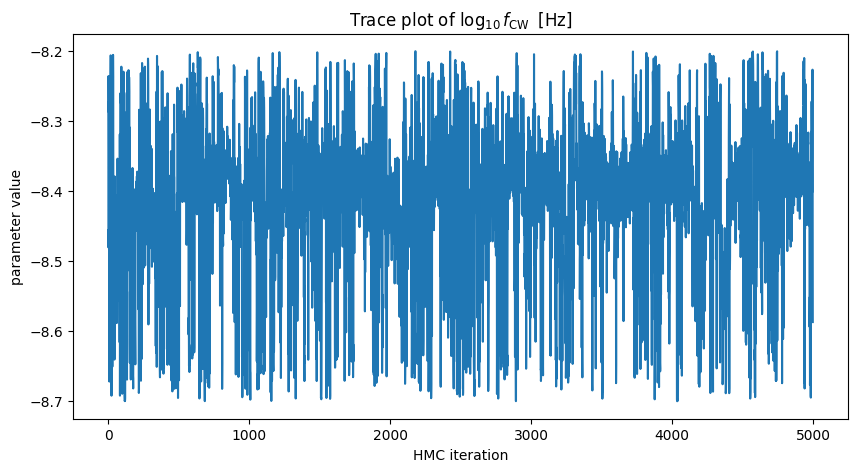

In [20]:
# trace plot of CW frequency parameter
plt.figure(figsize=(10, 5))
plt.plot(samples['cw_evolve'][:, 1])
plt.xlabel('HMC iteration')
plt.ylabel('parameter value')
plt.title(r'Trace plot of $\log_{10} f_\text{CW}\;\;[\text{Hz}]$')
plt.show()

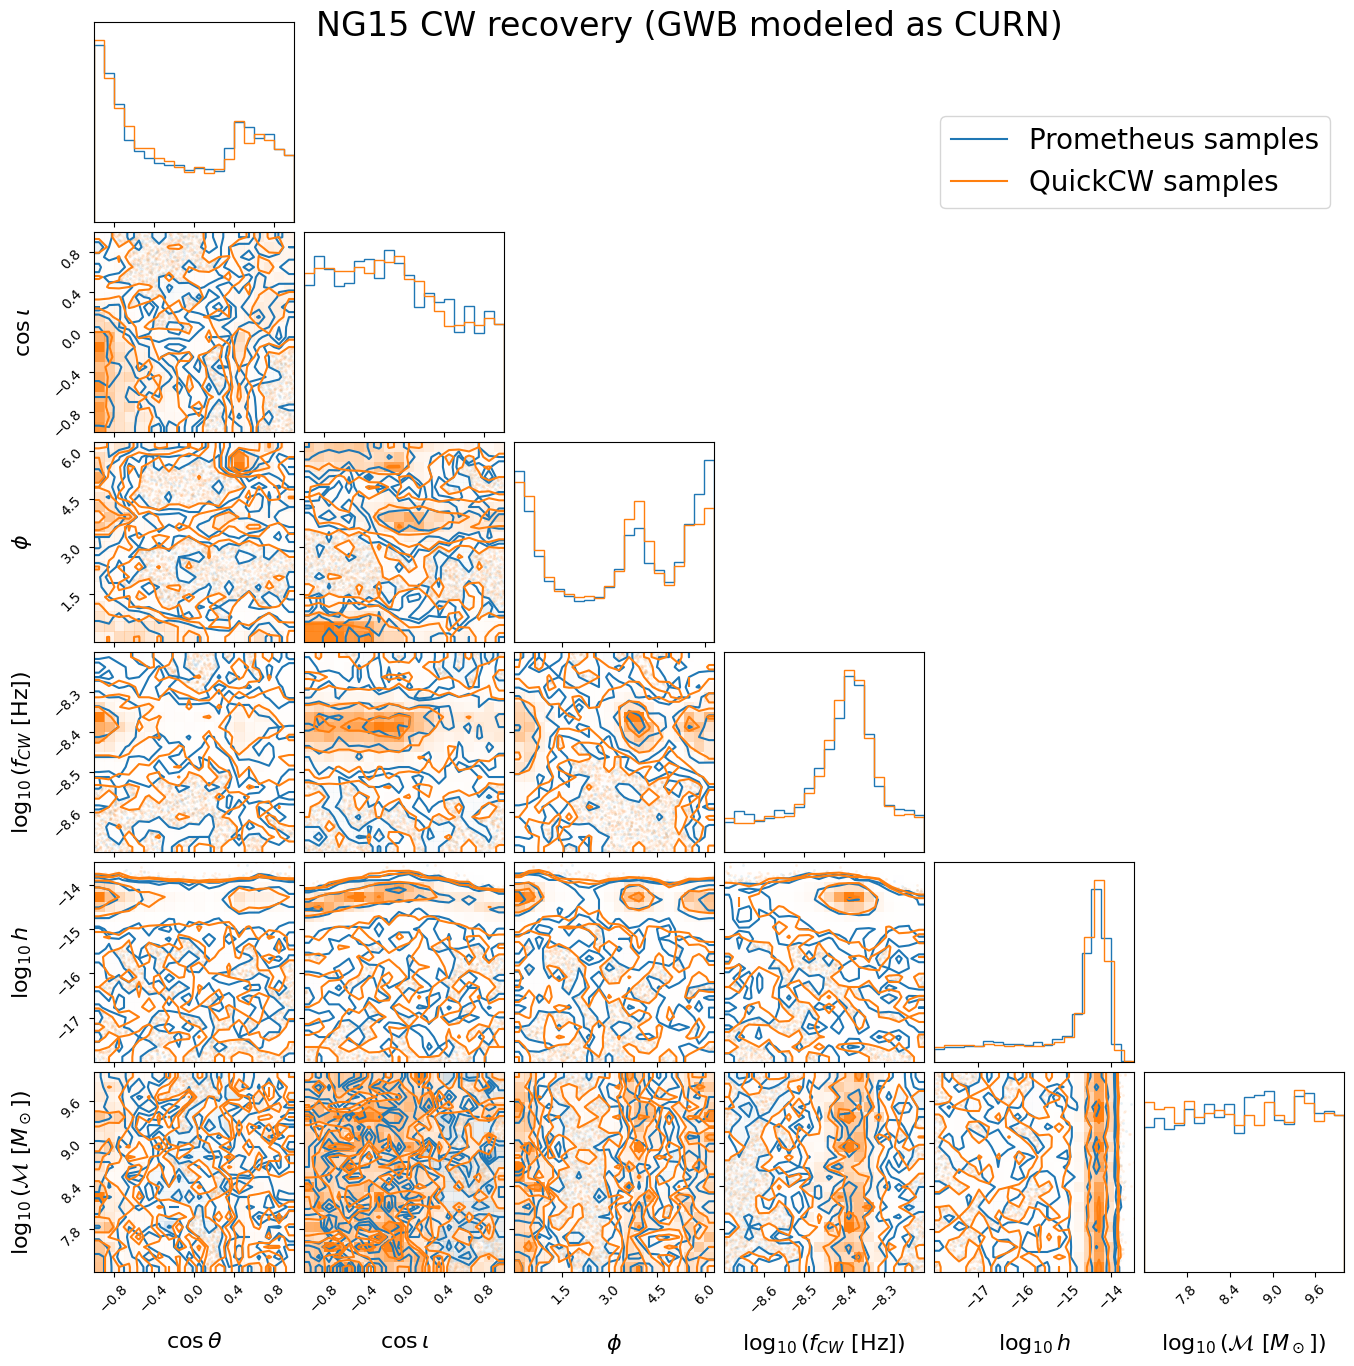

In [21]:
# plot CW recovery under CURN GWB model

# match parameter ordering of quickCW
ordering = np.array([-3, 2, -2, 1, 4, 0])

cw_source_labels = np.array([r'$\log_{10}(\mathcal{M}\,\,[M_\odot])$',
                             r'$\log_{10}(f_{CW}\,\,[\text{Hz}])$',
                             r'$\cos{\iota}$', r'$\psi$', r'$\log_{10} h$',
                             r'$\cos{\theta}$', r'$\phi$', r'$\Phi_0$'])

# plot samples from Prometheus
cw_samples = np.array(samples['cw_evolve'])
fig = corner.corner(cw_samples[:, ordering],
                    bins=20,
                    labels=cw_source_labels[ordering],
                    label_kwargs={'fontsize':16},
                    color='C0',
                    hist_kwargs={'density': True})

# plot samples from QuickCW
corner.corner(data=quickCW_samples[:, :-2],
              bins=20,
              fig=fig,
              color='C1',
              hist_kwargs={'density': True})

# plot legend/title
axes = np.array(fig.axes).reshape((len(ordering), len(ordering)))
axes[0, -1].plot([], [], color='C0', label='Prometheus samples')
axes[0, -1].plot([], [], color='C1', label='QuickCW samples')
axes[0, -1].legend(fontsize=20, loc='lower right')
fig.suptitle('NG15 CW recovery (GWB modeled as CURN)',
             fontsize=24)
fig.show()

## Bonus:

By default, **Prometheus** uses normal priors on the pulsar distance parameters, but those familiar with CW searches know that more technical priors are used ([Arzoumanian et al. 2023](https://arxiv.org/pdf/2301.03608) Eq. 20 & 21). We can modify the pulsar distance priors. First we'll code up our own prior density function. Then this prior function enters the `DeterministicModel` as `additional_ln_factor` which gets added to the log-posterior evaluation.

Similar methods may be used to modify other priors. For example, we sample in $\log_{10}h$ above, for which **Prometheus** uses a uniform prior (log-uniform in $h$). We can switch to a uniform prior in $h$ by adding the log-determinant of the Jacobian of this reparameterization.

In [ ]:
import jax.numpy as jnp

# which pulsar distances are measured with parallax and DM
where_PX = jnp.where(NG15_data.psr_dist_method == 'PX')[0]
where_DM = jnp.where(NG15_data.psr_dist_method == 'DM')[0]

# measured pulsar distance and uncertainty
psr_dists_measured = jnp.array(NG15_data.psr_dists_measured)
psr_dists_std = jnp.array(NG15_data.psr_dists_std)

# the additional prior weighting take the determinisitic model parameters as input
def psr_dists_lnprior(cw_source_params, psr_phases, psr_dists):

    # prior on pulsar distance when measured with parallax
    lnpriors_PX_dist = jax.vmap(lambda x, y, z : posterior.ln_p_PX(x, y, z),
                                in_axes=(0, 0, 0))(psr_dists, psr_dists_measured, psr_dists_std)
    lnprior_PX_summed = jnp.sum(lnpriors_PX_dist[where_PX])

    # prior on pulsar distance when measured with DM
    lnpriors_DM_dist = jax.vmap(lambda x, y, z : posterior.ln_p_DM(x, y, z),
                                in_axes=(0, 0, 0))(psr_dists, psr_dists_measured, psr_dists_std)
    lnprior_DM_summed = jnp.sum(lnpriors_DM_dist[where_DM])

    # Prometheus still samples pulsar distance using a normal prior,
    # so we must subtract that log-density here
    ln_normal_correction = 0.5 * jnp.sum((psr_dists - psr_dists_measured)**2 / psr_dists_std**2)

    # new "advanced" pulsar distance prior
    return lnprior_PX_summed + lnprior_DM_summed + ln_normal_correction

# now we can build the deterministic model using the new pulsar distance prior
new_cw_model = DeterministicModel(name='cw_evolve',
                                  data=NG15_data,
                                  get_delays_func=deterministic.cw_delay_evolve_low_freq_float32,
                                  parameter_bounds=cw_parameter_bounds,
                                  with_psr_params=True,
                                  additional_ln_factor=psr_dists_lnprior)

# and make a new PTA model with modified pulsar distance prior
pta_model_with_psr_dist_prior = PTAModel(psr_model=psr_model,
                                         gwb_model=gwb_model,
                                         det_model=new_cw_model)

In [23]:
# sample PTA model with modified pulsar distance prior

# # build the NumPyro NUTS kernel
# nuts_kernel = numpyro.infer.NUTS(model=pta_model_with_psr_dist_prior.sampling_model)

# # specify MCMC attributes
# mcmc = numpyro.infer.MCMC(sampler=nuts_kernel,
#                           num_warmup=500,
#                           num_samples=1000)

# # seed to start sampling
# # (see "WARNING" above: change if necessary)
# seed = 200129

# # run MCMC and get samples
# mcmc.run(jr.PRNGKey(seed))
# samples = mcmc.get_samples()